# Data Preprocessing

Our current standard for our retinal images is 520x520 pixels retaining color as it is critical for proper diagnosis.

In [ ]:
# Imports

import pandas as pd
import os

In [ ]:
# Importing Datasets from Kaggle

# kaggle api token can be generated in your profile settings : https://www.kaggle.com/settings
# save kaggle api token in secrets

from google.colab import userdata
!export KAGGLE_API_TOKEN={userdata.get('KAGGLE_API_TOKEN')}

import kagglehub

# Download latest version of datasets
ds1 = kagglehub.dataset_download("linabennaa/eye-disease-image-dataset-mendeley")
ds2 = kagglehub.dataset_download("jeftaadriel/oia-odir-dataset")
ds4 = kagglehub.dataset_download("jr2ngb/cataractdataset")

Using Colab cache for faster access to the 'eye-disease-image-dataset-mendeley' dataset.
Using Colab cache for faster access to the 'oia-odir-dataset' dataset.
Using Colab cache for faster access to the 'cataractdataset' dataset.


# Data Set 1

https://data.mendeley.com/datasets/s9bfhswzjb/1

https://www.kaggle.com/datasets/linabennaa/eye-disease-image-dataset-mendeley

- Coverage - Retinitis Pigmentosa, Retinal Detachment, Pterygium, Myopia, Macular Scar, Glaucoma, Disc Edema, Diabetic Retinopathy, Central Serous Chorioretinopathy
- Images - 16242 (# patients not confirmed)


In [ ]:
dataset_path = ds1 + '/Augmented Dataset'

image_paths = []
disease_labels = []

# Iterate through each disease folder
for disease_folder in os.listdir(dataset_path):
  disease_path = os.path.join(dataset_path, disease_folder)

  # Iterate through images in the disease folder
  for image_name in os.listdir(disease_path):

    image_full_path = os.path.join(disease_path, image_name)
    image_paths.append(image_full_path)
    disease_labels.append(disease_folder)

# Create a DataFrame
df_ds1 = pd.DataFrame({
  'image_path': image_paths,
  'eye_disease': disease_labels
})

print(df_ds1)

                                              image_path           eye_disease
0      /kaggle/input/eye-disease-image-dataset-mendel...          Macular Scar
1      /kaggle/input/eye-disease-image-dataset-mendel...          Macular Scar
2      /kaggle/input/eye-disease-image-dataset-mendel...          Macular Scar
3      /kaggle/input/eye-disease-image-dataset-mendel...          Macular Scar
4      /kaggle/input/eye-disease-image-dataset-mendel...          Macular Scar
...                                                  ...                   ...
16237  /kaggle/input/eye-disease-image-dataset-mendel...  Diabetic Retinopathy
16238  /kaggle/input/eye-disease-image-dataset-mendel...  Diabetic Retinopathy
16239  /kaggle/input/eye-disease-image-dataset-mendel...  Diabetic Retinopathy
16240  /kaggle/input/eye-disease-image-dataset-mendel...  Diabetic Retinopathy
16241  /kaggle/input/eye-disease-image-dataset-mendel...  Diabetic Retinopathy

[16242 rows x 2 columns]


# Data Set 2

https://www.kaggle.com/datasets/jeftaadriel/oia-odir-dataset

- NOTE: Labels are in Chinese and includes images for both eyes
- Coverage - DIABETIC_RETINOPATHY, GLAUCOMA, CATARACT, AGE_RELATED_MACULAR_DEGENERATION, HYPERTENSION, MYOPIA, OTHER_DISEASES
- Images - 13000 (10k train, 2k on site test, 1k off site test) (# patients not confirmed)

Since the rest of our datasets are for singular eyes, we will be splitting this dataset into left and right eye and classifying based on the diagnosis for each eye.



In [ ]:
# Convert files to csv format
off_site_file = pd.read_excel("/kaggle/input/oia-odir-dataset/Off-site Test Set/Annotation/off-site test annotation (English).xlsx")
off_site_file.to_csv("off_site_test_annotation.csv", index=None, header=True)

on_site_file = pd.read_excel("/kaggle/input/oia-odir-dataset/On-site Test Set/Annotation/on-site test annotation (English).xlsx")
on_site_file.to_csv("on_site_test_annotation.csv", index=None, header=True)

training_file = pd.read_excel("/kaggle/input/oia-odir-dataset/Training Set/Annotation/training annotation (English).xlsx")
training_file.to_csv("training_annotation.csv", index=None, header=True)

# Base paths for images
base_path_off_site = ds2 + '/Off-site Test Set/Images/'
base_path_on_site = ds2 + '/On-site Test Set/Images/'
base_path_training = ds2 + '/Training Set/Images/'

# Add image paths to a DataFrame
def process_fundus_image_paths(df, base_path, left_col='Left-Fundus', right_col='Right-Fundus'):
    def add_image_path(filename, current_base_path):
        if pd.isna(filename):
            return filename
        return os.path.join(current_base_path, filename)

    df[left_col] = df[left_col].apply(lambda x: add_image_path(x, base_path))
    df[right_col] = df[right_col].apply(lambda x: add_image_path(x, base_path))
    return df

# Apply to each DataFrame
off_site_file = process_fundus_image_paths(off_site_file, base_path_off_site)
on_site_file = process_fundus_image_paths(on_site_file, base_path_on_site)
training_file = process_fundus_image_paths(training_file, base_path_training)

# Combine all DataFrames into one
df_ds2 = pd.concat([off_site_file, on_site_file, training_file], ignore_index=True)

# Remove specified columns
columns_to_remove = ['ID', 'Patient Age', 'Patient Sex', 'N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']
df_ds2 = df_ds2.drop(columns=columns_to_remove)

# Convert Keywords into diagnosis for each eye
disease_mapping = {
    'normal': 'NORMAL',
    'diabetic retinopathy': 'DIABETIC_RETINOPATHY',
    'glaucoma': 'GLAUCOMA',
    'cataract': 'CATARACT',
    'macular degeneration': 'AGE_RELATED_MACULAR_DEGENERATION',
    'age-related macular degeneration': 'AGE_RELATED_MACULAR_DEGENERATION',
    'hypertensive retinopathy': 'HYPERTENSION',
    'myopia': 'MYOPIA',
}

df_left = df_ds2[['Left-Fundus', 'Left-Diagnostic Keywords']].copy()
df_right = df_ds2[['Right-Fundus', 'Right-Diagnostic Keywords']].copy()

df_left.columns = ['image_path', 'eye_disease']
df_right.columns = ['image_path', 'eye_disease']

# Get unique disease codes for column names
disease_codes = list(set(disease_mapping.values()))
disease_codes.append('OTHER_DISEASES')

def parse_diagnosis(df):
    # Initialize all disease columns with 0
    for disease in disease_codes:
        df[disease] = 0

    # Parse each row's diagnostic keywords
    for idx, keywords in df['eye_disease'].items():
        if pd.isna(keywords):
            continue

        # Convert to lowercase for matching
        keywords_lower = str(keywords).lower()

        disease_found = False

        # Check for each disease keyword in the mapping
        for keyword, disease_code in disease_mapping.items():
            if keyword in keywords_lower:
                df.at[idx, disease_code] = 1
                disease_found = True

        if not disease_found:
            df.at[idx, 'OTHER_DISEASES'] = 1

    df = df.drop('eye_disease', axis=1)

    return df

# Apply to both dataframes
df_left = parse_diagnosis(df_left)
df_right = parse_diagnosis(df_right)

# Combine to final dataset
df_ds2 = pd.concat([df_left, df_right], ignore_index=True)

print(df_left)
print(df_right)


                                             image_path  GLAUCOMA  CATARACT  \
0     /kaggle/input/oia-odir-dataset/Off-site Test S...         0         0   
1     /kaggle/input/oia-odir-dataset/Off-site Test S...         0         0   
2     /kaggle/input/oia-odir-dataset/Off-site Test S...         0         0   
3     /kaggle/input/oia-odir-dataset/Off-site Test S...         0         0   
4     /kaggle/input/oia-odir-dataset/Off-site Test S...         0         0   
...                                                 ...       ...       ...   
4995  /kaggle/input/oia-odir-dataset/Training Set/Im...         0         0   
4996  /kaggle/input/oia-odir-dataset/Training Set/Im...         0         0   
4997  /kaggle/input/oia-odir-dataset/Training Set/Im...         0         0   
4998  /kaggle/input/oia-odir-dataset/Training Set/Im...         0         0   
4999  /kaggle/input/oia-odir-dataset/Training Set/Im...         0         0   

      MYOPIA  NORMAL  AGE_RELATED_MACULAR_DEGENERAT

# Data Set 3

https://github.com/nkicsl/DDR-dataset/blob/master/README.md
https://drive.google.com/drive/folders/1z6tSFmxW_aNayUqVxx6h6bY4kwGzUTEC
https://www.sciencedirect.com/science/article/pii/S0020025519305377

- Coverage - Diabetic retinopathy
- Images - 13673 images from 9598 patients


In [ ]:
!pip -q install gdown pyarrow

In [ ]:
# imports
import os
import zipfile
from pathlib import Path
import pandas as pd
import gdown

In [ ]:
folder_link_3 = "https://drive.google.com/drive/folders/1z6tSFmxW_aNayUqVxx6h6bY4kwGzUTEC"

In [ ]:
download_folder_3 = "/content/gdrive_public"
os.makedirs(download_folder_3, exist_ok=True)

result_3 = gdown.download_folder(
	url = folder_link_3,
	output = download_folder_3,
	quiet = False,
	use_cookies = False
)

Retrieving folder contents


Processing file 1_gmRXJ3Wc9lNScbAlC3Jt1zOwpFHfDgE DDR-dataset.zip.001
Processing file 14a5HcSTtGwEchKMpUGieuv0rNfm0Mbs9 DDR-dataset.zip.002
Processing file 10i8OzBuHqPICgrkxoGLpHPy_3nDg0buX DDR-dataset.zip.003
Processing file 1-26gAtV2TsoLioT3BsL8S5sieHLW3z-c DDR-dataset.zip.004
Processing file 1joj-KN556wtnzipQ54OpPBMXM-pW-oJ9 DDR-dataset.zip.005
Processing file 1rNV-yqdcG5j9ZA05G0lmiZUc3xK7YRFv DDR-dataset.zip.006
Processing file 12U7sn-8UwBgeL5pY7EOYUJAyqjFxTHS6 DDR-dataset.zip.007
Processing file 1fJwdYVO8_lDeJI8ic1yr7sl5RtqYfxOW DDR-dataset.zip.008
Processing file 1rrWddjsrmrwKQVCWU9x7onVkgMdtv0Wf DDR-dataset.zip.009
Processing file 1RxRx_ImIDAmUp1h8BNaqVJ9LJ0jCmyua DDR-dataset.zip.010


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1_gmRXJ3Wc9lNScbAlC3Jt1zOwpFHfDgE
From (redirected): https://drive.google.com/uc?id=1_gmRXJ3Wc9lNScbAlC3Jt1zOwpFHfDgE&confirm=t&uuid=2f46e6f1-1568-43f9-8236-87869eeff575
To: /content/gdrive_public/DDR-dataset.zip.001
100%|██████████| 1.57G/1.57G [00:22<00:00, 69.1MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=14a5HcSTtGwEchKMpUGieuv0rNfm0Mbs9
From (redirected): https://drive.google.com/uc?id=14a5HcSTtGwEchKMpUGieuv0rNfm0Mbs9&confirm=t&uuid=29341879-7b81-4f3d-952e-d918e8cf2cfc
To: /content/gdrive_public/DDR-dataset.zip.002
100%|██████████| 1.57G/1.57G [00:19<00:00, 82.5MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=10i8OzBuHqPICgrkxoGLpHPy_3nDg0buX
From (redirected): https://drive.google.com/uc?id=10i8OzBuHqPICgrkxoGLpHPy_3nDg0buX&confirm=t&uuid=999d1e46-6492-4683-af79-da63f1fa8

In [ ]:
# combining the zip files into one zip file
parts = sorted(Path(download_folder_3).glob("DDR-dataset.zip.*"))
combined_zip = Path(download_folder_3) / "DDR-dataset.zip"

with open(combined_zip, "wb") as outfile:
  for part in parts:
      with open(part, "rb") as infile:
        outfile.write(infile.read())

# unzipping the main zip file
extract_folders_3 = "/content/extracted"
os.makedirs(extract_folders_3, exist_ok=True)

with zipfile.ZipFile(combined_zip, "r") as zf:
  zf.extractall(extract_folders_3)

all_files_extracted = [p for p in Path(extract_folders_3).rglob("*") if p.is_file()]

print(extract_folders_3)

/content/extracted


Number of images:
14430
Counter({'.jpg': 14430, '.tif': 3028, '.xml': 757, '.txt': 3})
/content/extracted/DDR-dataset/lesion_segmentation/valid/segmentation label/SE/007-6161-300.tif


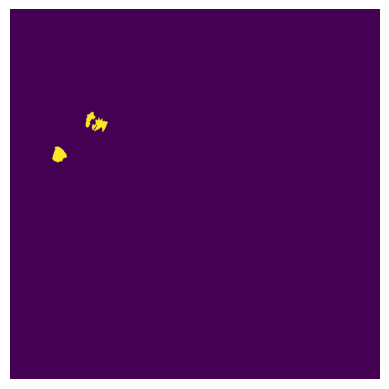

/content/extracted/DDR-dataset/lesion_segmentation/valid/image/007-7025-400.jpg
/content/extracted/DDR-dataset/lesion_detection/valid/20170602084034474.xml
<annotation>
    <folder>OurDataset</folder>
    <filename>20170602084034474.jpg</filename>
    <size>
        <width>3264</width>
        <height>2448</height>
        <depth>3</depth>
    </size>
    <object>
        <name>ma</name>
        <pose>Unspecified</pose>
        <truncated>0</truncated>
        <difficult>0</difficult>
        <bndbox>
            <xmin>1491</xmin>
            <ymin>1525</ymin>
            <xmax>1499</xmax>
            <ymax>1533</ymax>
        </bndbox>
    </object>
    <object>
        <name>ma</name>
        <pose>Unspecified</pose>
        <truncated>0</truncated>
        <difficult>0</difficult>
        <bndbox>
            <xmin>1679</xmin>
            <ymin>1559</ymin>
            <xmax>1687</xmax>
            <ymax>1577</ymax>
        </bndbox>
    </object>
    <object>
        <name>ma</name>

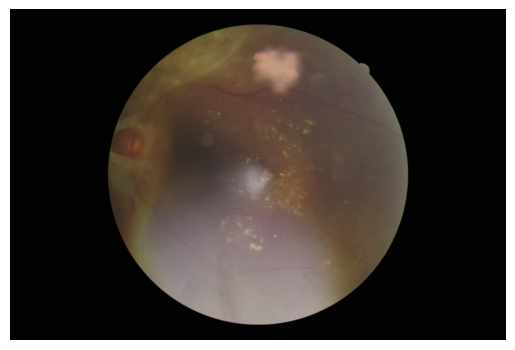

In [ ]:
# examining the file
# checking number of images we have
num_jpg = sum(1 for f in all_files_extracted if str(f).lower().endswith(".jpg"))
print("Number of images:")
print(num_jpg)

# checking file types
from collections import Counter
file_types = Counter(f.suffix.lower() for f in all_files_extracted if f.is_file())
print(file_types)

# checking tif files
from PIL import Image
import matplotlib.pyplot as plt

tif_file = next(f for f in all_files_extracted if f.suffix.lower() ==".tif")
print(tif_file)

img = Image.open(tif_file)
plt.imshow(img)
plt.axis("off")
plt.show()

# checking jpg files
jpg_file = next(f for f in all_files_extracted if f.suffix.lower() == ".jpg")
print(jpg_file)

# checking the xml files
xml_file = next(f for f in all_files_extracted if f.suffix.lower() == ".xml")
print(xml_file) # getting the file name

with open(xml_file, "r", encoding="utf-8", errors="ignore") as f:
  xml_text = f.read()

print(xml_text)

img = Image.open(jpg_file)
plt.imshow(img)
plt.axis("off")
plt.show()

The tif and xml files are not retinal fundus images, so we have removed them from our dataset.

In [ ]:
# removing xml and tif files from all_files_extracted
all_files_extracted = [f for f in all_files_extracted if f.suffix.lower() not in [".tif", ".xml"]]

# checking file types
from collections import Counter
file_types = Counter(f.suffix.lower() for f in all_files_extracted if f.is_file())
print(file_types)

# copying over the 3 txt files that contain the training, validation, and test set information
txt_files = [f for f in all_files_extracted if f.suffix.lower() == ".txt"]

# remove from all_files_extracted
all_files_extracted = [f for f in all_files_extracted if f.suffix.lower() == ".jpg"]

Counter({'.jpg': 14430, '.txt': 3})


In [ ]:
# creating pandas dataframe
# looking up filename
jpg_lookup = {Path(f).name: str(f) for f in all_files_extracted}

# parsing txt file
rows = []

for txt in txt_files:
  with open(txt, "r", encoding="utf-8", errors="ignore") as f:
    for line in f:
      line = line.strip()
      if not line:
        continue

      parts = line.split()
      if len(parts) < 2:
        continue

      jpg_path = parts[0]
      classification = parts[1]

      full_path = jpg_lookup.get(jpg_path)

      rows.append({
          "jpg_path": full_path,
          "classification": classification
      })

df_ds3 = pd.DataFrame(rows)

# convert "classification" column values into integer (they're currently string)
df_ds3["classification"] = df_ds3["classification"].astype(int)

# add new column for indicating whether patient has diabetic retinopathy
df_ds3["diabetic_retinopathy"] = (df_ds3["classification"] > 0).astype(int)

# Data Set 4

https://www.kaggle.com/datasets/jr2ngb/cataractdataset

https://github.com/yiweichen04/retina_dataset

- NOTE: This dataset does not have additional information on the patients, just image and their classification
- Coverage & # Images - total of 601 images
  - Normal (300  images)
  - Cataract (100 images)
  - Glaucoma (101 images)
  - Retina diseases (100 images)

In [ ]:
dataset_path = ds4 + '/dataset'

image_paths = []
disease_labels = []

# Iterate through each disease folder
for disease_folder in os.listdir(dataset_path):
  disease_path = os.path.join(dataset_path, disease_folder)

  # Iterate through images in the disease folder
  for image_name in os.listdir(disease_path):

    image_full_path = os.path.join(disease_path, image_name)
    image_paths.append(image_full_path)
    disease_labels.append(disease_folder)

# Create a DataFrame
df_ds4 = pd.DataFrame({
  'image_path': image_paths,
  'eye_disease': disease_labels
})

# Clean eye_disease column -- remove numbers and underscores
df_ds4['eye_disease'] = df_ds4['eye_disease'].apply(lambda x: ' '.join(x.split('_')[1:]))

# Removing rows with retina disease -- since it is a general term and not a specific condition
df_ds4 = df_ds4[df_ds4['eye_disease'] != 'retina disease']

print(df_ds4)

                                            image_path eye_disease
100  /kaggle/input/cataractdataset/dataset/2_catara...    cataract
101  /kaggle/input/cataractdataset/dataset/2_catara...    cataract
102  /kaggle/input/cataractdataset/dataset/2_catara...    cataract
103  /kaggle/input/cataractdataset/dataset/2_catara...    cataract
104  /kaggle/input/cataractdataset/dataset/2_catara...    cataract
..                                                 ...         ...
596  /kaggle/input/cataractdataset/dataset/2_glauco...    glaucoma
597  /kaggle/input/cataractdataset/dataset/2_glauco...    glaucoma
598  /kaggle/input/cataractdataset/dataset/2_glauco...    glaucoma
599  /kaggle/input/cataractdataset/dataset/2_glauco...    glaucoma
600  /kaggle/input/cataractdataset/dataset/2_glauco...    glaucoma

[501 rows x 2 columns]


# Data Set 5

https://universe.roboflow.com/asmaa-qubdi/eye-diseases-7ng7m

- NOTE: The labels are in the png names…
- Coverage: Central Serous Chorioretinopathy, Diabetic Retinopathy, disc edema, glaucoma, macular scar, myopia, pterygium, retinal detachment, retinitis pigmentosa
- Images - 8425 images


In [ ]:
folder_link = "https://drive.google.com/drive/folders/1uoklEveAWV-yiaG9bWSv69jskgh_ySCs?usp=sharing"

In [ ]:
download_folder = "/content/gdrive_public"
os.makedirs(download_folder, exist_ok=True)

result = gdown.download_folder(
	url = folder_link,
	output = download_folder,
	quiet = False,
	use_cookies = False
)

# get file in result
zip_path = next(f for f in result if f.endswith(".zip"))

extract_to = os.path.splitext(zip_path)[0]
os.makedirs(extract_to, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zf:
  zf.extractall(extract_to)

# extracting all jpg files and putting them into one folder
import shutil

source = Path("/content/gdrive_public/Eye diseases.v1i.folder")
target = Path("/content/all_jpgs")
target.mkdir(parents=True, exist_ok=True)

jpg_files = list(source.rglob("*.jpg"))
print("Total images:", len(jpg_files))

for img_path in jpg_files:
  shutil.copy2(img_path, target / img_path.name)
# stored all of the jpg paths into target

# extracting classification
class_map = {
    "CSC": "Central Serous Chorioretinopathy",
    "DR": "Diabetic Retinopathy",
    "Disc-Edema": "Disc Edema",
    "Glaucoma": "Glaucoma",
    "Healthy": "Healthy",
    "Macular-Scar": "Macular Scar",
    "Myopia": "Myopia",
    "Pterygium": "Pterygium",
    "Retinal-Detachment": "Retinal Detachment",
    "Retinitis-Pigmentosa": "Retinitis Pigmentosa",
}

rows = []

for img_path in target.glob("*.jpg"):
  filename = img_path.name

  label = None
  for prefix, class_name in class_map.items():
    if filename.startswith(prefix):
      label = class_name
      break

  rows.append({
      "jpg_path": str(img_path),
      "classification": label
  })

df_ds5 = pd.DataFrame(rows)

Retrieving folder contents


Processing file 1ejOBSpqz9rzkrcdKoG0DkJtbGFglN9UR Eye diseases.v1i.folder.zip


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1ejOBSpqz9rzkrcdKoG0DkJtbGFglN9UR
From (redirected): https://drive.google.com/uc?id=1ejOBSpqz9rzkrcdKoG0DkJtbGFglN9UR&confirm=t&uuid=7f4998f8-2417-4bc8-bc39-57f92df67c9e
To: /content/gdrive_public/Eye diseases.v1i.folder.zip
100%|██████████| 1.40G/1.40G [00:17<00:00, 81.4MB/s]
Download completed


Total images: 9160


# Data Set 6

https://github.com/openmedlab/Awesome-Medical-Dataset/blob/main/resources/Multi-LabelRetinalDiseases.md

- Coverage: Diabetic Retinopathy, media haze, optic disc cupping, tessellation, age-related macular degeneration, drusen, myopia, branch retinal vein occlusion, optic disc pallor, central retinal vein occlusion, choroidal neovascularization, retinitis, optic disc edema, laser scars, central serious retinopathy, hypertensive retinopathy, arteriosclerotic retinopathy, chorioretinitis, other diseases
- Images - 2208 images
- Resolution types - ranging from 520x520 to 3400x2800


In [ ]:
folder_link_6 = "https://drive.google.com/drive/folders/1NO7LASTtbYvfE6-2lKGp2rAJXiSISHee?usp=sharing"

download_folder_6 = "/content/gdrive_public"
os.makedirs(download_folder_6, exist_ok=True)

result_6 = gdown.download_folder(
	url = folder_link_6,
	output = download_folder_6,
	quiet = False,
	use_cookies = False
)

# save the files separately
images_zip, train_data_csv, val_data_csv = result_6

# unzip images
extract_dir = "/content/gdrive_public/images"
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(images_zip, "r") as zip_ref:
  zip_ref.extractall(extract_dir)

# checking the images within extract_dir
all_images = list(Path(extract_dir).rglob("*"))

Retrieving folder contents


Processing file 11nJZrKAhepO_zZ5Ef15QADsIG39y4lzZ images.zip
Processing file 1xtDYMkkr20Xm4FDxV4FHIhrJ8-A-tImm train_data_8.csv
Processing file 1lYk5996KZ7DEHDirKlrbWHoTvkvt2ix- val_data_8.csv


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=11nJZrKAhepO_zZ5Ef15QADsIG39y4lzZ
From (redirected): https://drive.google.com/uc?id=11nJZrKAhepO_zZ5Ef15QADsIG39y4lzZ&confirm=t&uuid=9c5ebd83-9ada-4499-a356-682a26a4782a
To: /content/gdrive_public/images.zip
100%|██████████| 5.44G/5.44G [00:58<00:00, 92.5MB/s]
Downloading...
From: https://drive.google.com/uc?id=1xtDYMkkr20Xm4FDxV4FHIhrJ8-A-tImm
To: /content/gdrive_public/train_data_8.csv
100%|██████████| 80.1k/80.1k [00:00<00:00, 66.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=1lYk5996KZ7DEHDirKlrbWHoTvkvt2ix-
To: /content/gdrive_public/val_data_8.csv
100%|██████████| 20.1k/20.1k [00:00<00:00, 19.5MB/s]
Download completed


/content/gdrive_public/images/images/aria_c_28_19.tif


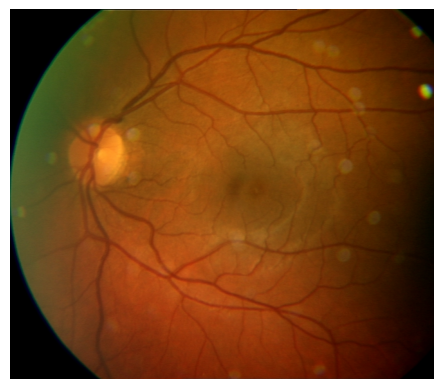

In [ ]:
# check the tif images
from PIL import Image
import matplotlib.pyplot as plt
tif_first = next((p for p in all_images if str(p).lower().endswith(".tif")), None)
print(tif_first)
img = Image.open(tif_first)
plt.imshow(img)
plt.axis("off")
plt.show()

/content/gdrive_public/images/images/885.png


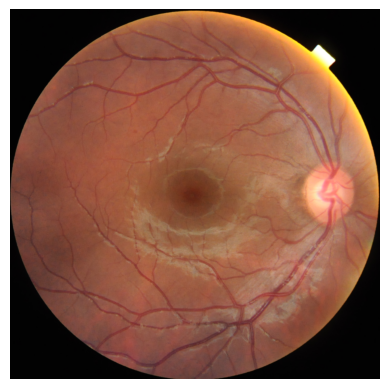

In [ ]:
# check the png images
from PIL import Image
import matplotlib.pyplot as plt
png_first = next((p for p in all_images if str(p).lower().endswith(".png")), None)
print(png_first)
img = Image.open(png_first)
plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
# combine the train and validation set into one
temp_df = pd.concat([pd.read_csv(train_data_csv), pd.read_csv(val_data_csv)], ignore_index=True)

# adding image path to temp_df
image_path_map = {
    Path(p).stem: str(p)
    for p in all_images
}

df_ds6 = temp_df.copy()
df_ds6["image_path"] = df_ds6["ID"].astype(str).map(image_path_map)

# remove ID column from df_ds6
df_ds6.drop(columns=["ID"], inplace=True)

# EDA

In [ ]:
import matplotlib.pyplot as plt

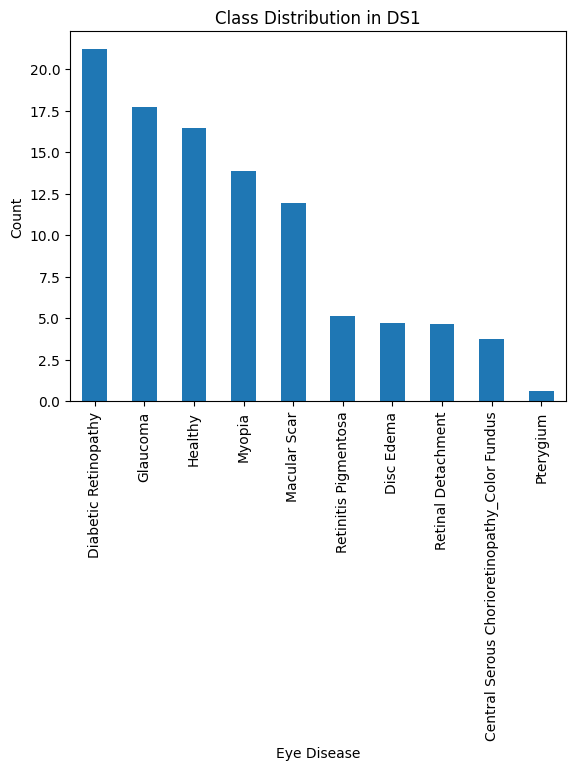

In [ ]:
# Start with checking the class distributions for each of the dataframes

class_counts_ds1 = df_ds1["eye_disease"].value_counts() / len(df_ds1) * 100
class_counts_ds1.plot(kind="bar", title="Class Distribution in DS1")
plt.xlabel("Eye Disease")
plt.ylabel("Count")
plt.show()

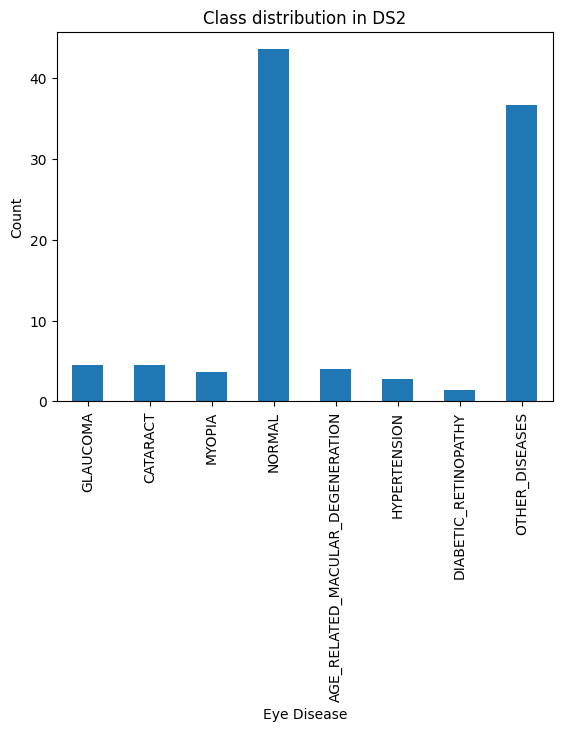

In [ ]:
class_counts_ds2 = df_ds2.drop(columns= ["image_path"]).sum()/len(df_ds2) * 100
class_counts_ds2.plot(kind="bar", title="Class distribution in DS2")
plt.xlabel("Eye Disease")
plt.ylabel("Count")
plt.show()

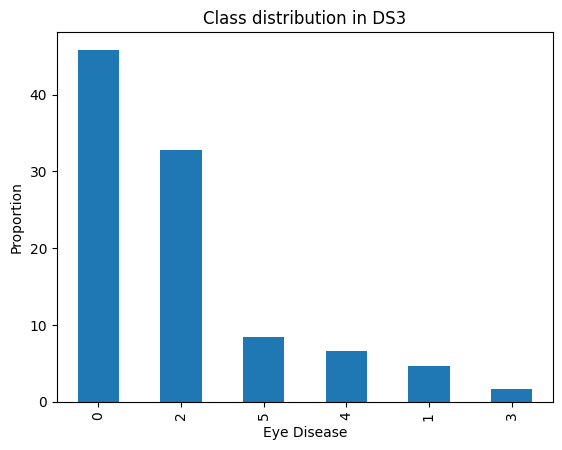

In [ ]:
class_counts_ds3 = df_ds3[''].value_counts() / len(df_ds3) * 100
class_counts_ds3.plot(kind="bar", title="Class distribution in DS3")
plt.xlabel("Eye Disease")
plt.ylabel("Proportion")
plt.show()

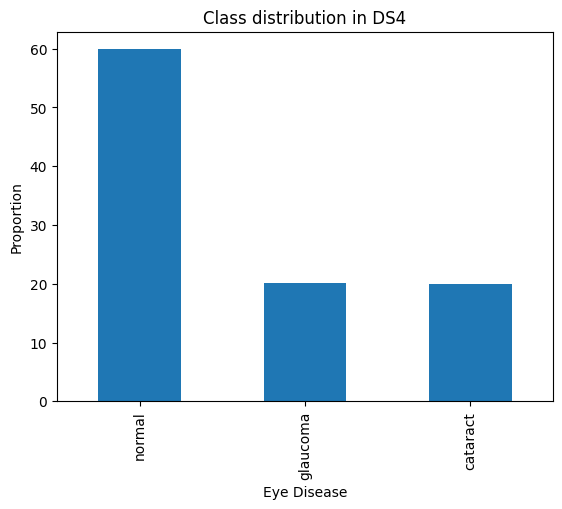

In [ ]:
class_counts_ds4 = df_ds4['eye_disease'].value_counts() / len(df_ds4) * 100
class_counts_ds4.plot(kind="bar", title="Class distribution in DS4")
plt.xlabel("Eye Disease")
plt.ylabel("Proportion")
plt.show()

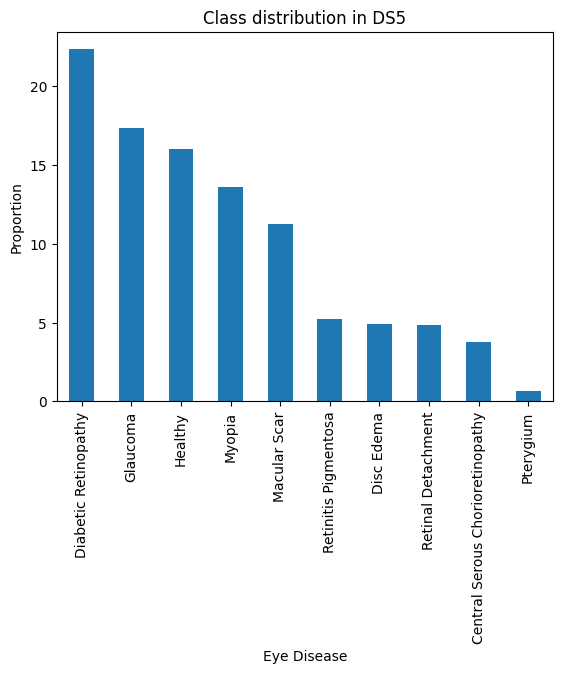

In [ ]:

class_counts_ds5 = df_ds5['classification'].value_counts() / len(df_ds5) * 100
class_counts_ds5.plot(kind="bar", title="Class distribution in DS5")
plt.xlabel("Eye Disease")
plt.ylabel("Proportion")
plt.show()

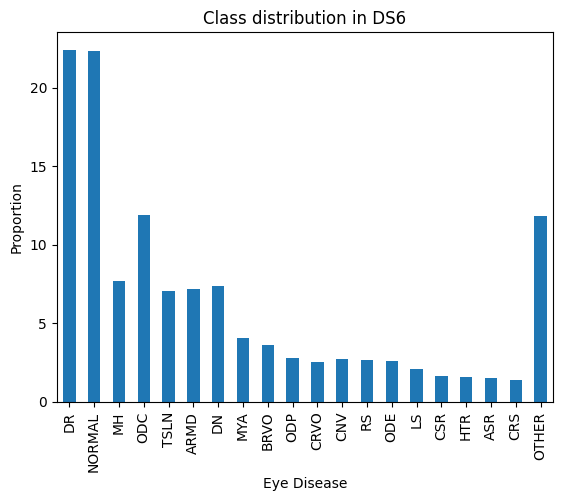

In [ ]:
class_counts_ds6 = df_ds6.drop(columns=['image_path']).sum() / len(df_ds6) * 100
class_counts_ds6.plot(kind="bar", title="Class distribution in DS6")
plt.xlabel("Eye Disease")
plt.ylabel("Proportion")
plt.show()

# Combining the datsets into 1

In [ ]:
df_ds1.head()

,image_path,eye_disease
0,/kaggle/input/eye-disease-image-dataset-mendel...,Macular Scar
1,/kaggle/input/eye-disease-image-dataset-mendel...,Macular Scar
2,/kaggle/input/eye-disease-image-dataset-mendel...,Macular Scar
3,/kaggle/input/eye-disease-image-dataset-mendel...,Macular Scar
4,/kaggle/input/eye-disease-image-dataset-mendel...,Macular Scar


In [ ]:
df_ds1_encoded = pd.get_dummies(df_ds1,columns = ['eye_disease'], prefix="", prefix_sep="", dtype=int)
df_ds1_encoded = df_ds1_encoded.rename(columns = {'Central Serous Chorioretinopathy_Color Fundus': 'Central Serous Retinopathy', 'Disc Edema': 'Optic Disc Edema','Healthy':'normal' })
df_ds1_encoded.columns = df_ds1_encoded.columns.str.upper()
df_ds1_encoded.columns = df_ds1_encoded.columns.str.replace(' ', '_')
df_ds1_encoded.head()

,IMAGE_PATH,CENTRAL_SEROUS_RETINOPATHY,DIABETIC_RETINOPATHY,OPTIC_DISC_EDEMA,GLAUCOMA,NORMAL,MACULAR_SCAR,MYOPIA,PTERYGIUM,RETINAL_DETACHMENT,RETINITIS_PIGMENTOSA
0,/kaggle/input/eye-disease-image-dataset-mendel...,0,0,0,0,0,1,0,0,0,0
1,/kaggle/input/eye-disease-image-dataset-mendel...,0,0,0,0,0,1,0,0,0,0
2,/kaggle/input/eye-disease-image-dataset-mendel...,0,0,0,0,0,1,0,0,0,0
3,/kaggle/input/eye-disease-image-dataset-mendel...,0,0,0,0,0,1,0,0,0,0
4,/kaggle/input/eye-disease-image-dataset-mendel...,0,0,0,0,0,1,0,0,0,0


In [ ]:
df_ds2_encoded = df_ds2.drop(columns=["OTHER_DISEASES"])
df_ds2_encoded.columns = df_ds2_encoded.columns.str.upper()

,IMAGE_PATH,GLAUCOMA,CATARACT,MYOPIA,NORMAL,AGE_RELATED_MACULAR_DEGENERATION,HYPERTENSION,DIABETIC_RETINOPATHY
0,/kaggle/input/oia-odir-dataset/Off-site Test S...,0,0,0,0,0,1,0
1,/kaggle/input/oia-odir-dataset/Off-site Test S...,0,0,0,0,0,0,0
2,/kaggle/input/oia-odir-dataset/Off-site Test S...,0,0,0,0,0,0,0
3,/kaggle/input/oia-odir-dataset/Off-site Test S...,0,0,0,0,0,0,0
4,/kaggle/input/oia-odir-dataset/Off-site Test S...,0,0,0,0,0,0,0


In [ ]:
df_ds3_encoded = pd.get_dummies(df_ds3, columns = ['diabetic_retinopathy'], prefix="", prefix_sep="", dtype=int).drop(columns=["classification"])
df_ds3_encoded = df_ds3_encoded.rename(columns={'jpg_path': 'image_path', '0': 'NORMAL', '1': 'DIABETIC_RETINOPATHY'})
df_ds3_encoded.columns = df_ds3_encoded.columns.str.upper()
df_ds3_encoded.head()

,IMAGE_PATH,NORMAL,DIABETIC_RETINOPATHY
0,/content/extracted/DDR-dataset/DR_grading/trai...,1,0
1,/content/extracted/DDR-dataset/DR_grading/trai...,1,0
2,/content/extracted/DDR-dataset/DR_grading/trai...,1,0
3,/content/extracted/DDR-dataset/DR_grading/trai...,1,0
4,/content/extracted/DDR-dataset/DR_grading/trai...,1,0


In [ ]:
df_ds4_encoded = pd.get_dummies(df_ds4, columns=['eye_disease'], prefix="", prefix_sep="", dtype=int)
df_ds4_encoded.columns = df_ds4_encoded.columns.str.upper()
df_ds4_encoded.head()

,IMAGE_PATH,CATARACT,GLAUCOMA,NORMAL
100,/kaggle/input/cataractdataset/dataset/2_catara...,1,0,0
101,/kaggle/input/cataractdataset/dataset/2_catara...,1,0,0
102,/kaggle/input/cataractdataset/dataset/2_catara...,1,0,0
103,/kaggle/input/cataractdataset/dataset/2_catara...,1,0,0
104,/kaggle/input/cataractdataset/dataset/2_catara...,1,0,0


In [ ]:
df_ds5_encoded = pd.get_dummies(df_ds5, columns=['classification'], prefix="", prefix_sep="", dtype=int)
df_ds5_encoded = df_ds5_encoded.rename(columns={'Healthy': 'NORMAL', 'jpg_path': 'image_path'})
df_ds5_encoded.columns = df_ds5_encoded.columns.str.upper()
df_ds5_encoded.columns = df_ds5_encoded.columns.str.replace(' ', '_')
df_ds5_encoded.head()

,IMAGE_PATH,CENTRAL_SEROUS_CHORIORETINOPATHY,DIABETIC_RETINOPATHY,DISC_EDEMA,GLAUCOMA,NORMAL,MACULAR_SCAR,MYOPIA,PTERYGIUM,RETINAL_DETACHMENT,RETINITIS_PIGMENTOSA
0,/content/all_jpgs/DR1873_jpg.rf.f0f8dce223afcc...,0,1,0,0,0,0,0,0,0,0
1,/content/all_jpgs/Myopia888_jpg.rf.dfeecf61f61...,0,0,0,0,0,0,1,0,0,0
2,/content/all_jpgs/Healthy1142_jpg.rf.ec37b8f84...,0,0,0,0,1,0,0,0,0,0
3,/content/all_jpgs/Glaucoma494_jpg.rf.6fccdc368...,0,0,0,1,0,0,0,0,0,0
4,/content/all_jpgs/Glaucoma1520_jpg.rf.a4a27e51...,0,0,0,1,0,0,0,0,0,0


In [ ]:
df_ds6_encoded = df_ds6.rename(columns={'DR': 'DIABETIC_RETINOPATHY', 'MH':'MEDIA_HAZE', 'ODC': 'OPTIC_DISC_CUPPING', 'TSLN':'TESSELLATION', 'ARMD':'AGE-RELATED_MACULAR_DEGENERATION', 'DN':'DRUSEN', 'MYA':'MYOPIA', 'BRVO':'BRANCH_RETINAL_VEIN_OCCLUSION', 'ODP':'OPTIC_DISC_PALLOR', 'CRVO':'CENTRAL_RETINAL_VEIN_OCCLUSION', 'CNV':'CHOROIDAL NEOVASCULARIZATION', 'RS':'RETINITIS', 'ODE':'OPTIC_DISC_EDEMA', 'LS':'LASER_SCARS', 'CSR':'CENTRAL_SEROUS_RETINOPATHY', 'HTR':'HYPERTENSIVE_RETINOPATHY', 'ASR':'ARTERIOSCLEROTIC_RETINOPATHY', 'CRS':'CHORIORETINITIS'})
df_ds6_encoded = df_ds6_encoded.drop(columns=['OTHER'])
df_ds6_encoded.columns = df_ds6_encoded.columns.str.upper()

,DIABETIC_RETINOPATHY,NORMAL,MEDIA_HAZE,OPTIC_DISC_CUPPING,TESSELLATION,AGE-RELATED_MACULAR_DEGENERATION,DRUSEN,MYOPIA,BRANCH_RETINAL_VEIN_OCCLUSION,OPTIC_DISC_PALLOR,CENTRAL_RETINAL_VEIN_OCCLUSION,CHOROIDAL NEOVASCULARIZATION,RETINITIS,OPTIC_DISC_EDEMA,LASER_SCARS,CENTRAL_SEROUS_RETINOPATHY,HYPERTENSIVE_RETINOPATHY,ARTERIOSCLEROTIC_RETINOPATHY,CHORIORETINITIS,IMAGE_PATH
0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,/content/gdrive_public/images/images/aria_c_25...
1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,/content/gdrive_public/images/images/aria_c_7_...
2,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,/content/gdrive_public/images/images/aria_c_38...
3,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,/content/gdrive_public/images/images/aria_c_2_...
4,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,/content/gdrive_public/images/images/aria_c_26...


In [ ]:
df_full_encoded = pd.concat([df_ds1_encoded, df_ds2_encoded, df_ds3_encoded, df_ds4_encoded, df_ds5_encoded, df_ds6_encoded], ignore_index=True).fillna(0)

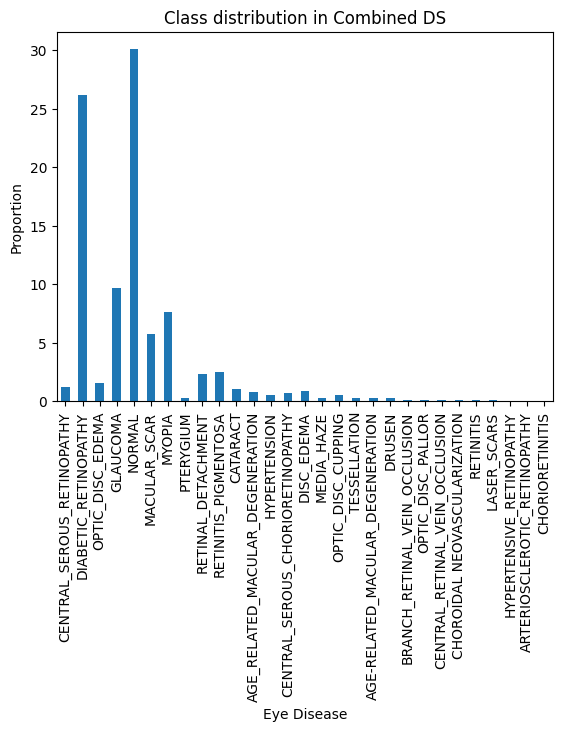

In [ ]:
class_counts_full= df_full_encoded.drop(columns=['IMAGE_PATH', 'RESOLUTION', 'WIDTH', 'HEIGHT']).sum()/len(df_full_encoded) * 100

class_counts_full.plot(kind="bar", title="Class distribution in Combined DS")
plt.xlabel("Eye Disease")
plt.ylabel("Proportion")
plt.show()

In [ ]:
from PIL import Image

def get_resolution(path):
  with Image.open(path) as img:
    return img.size

df_full_encoded['RESOLUTION'] = df_full_encoded['IMAGE_PATH'].apply(get_resolution)

In [ ]:
df_full_encoded['WIDTH'] = df_full_encoded['RESOLUTION'].apply(lambda x: x[0])
df_full_encoded['HEIGHT'] = df_full_encoded['RESOLUTION'].apply(lambda x: x[1])

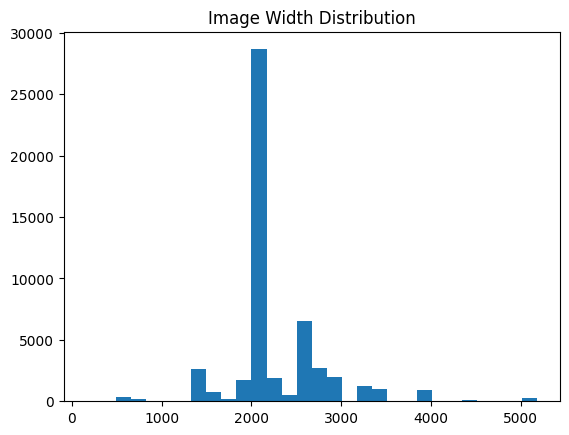

In [ ]:

plt.hist(df_full_encoded["WIDTH"], bins=30)
plt.title("Image Width Distribution")
plt.show()

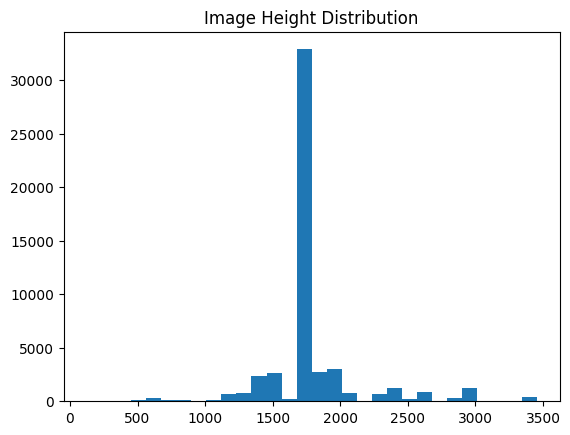

In [ ]:
plt.hist(df_full_encoded["HEIGHT"], bins=30)
plt.title("Image Height Distribution")
plt.show()